In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv("house_prices_practice.csv")

In [ ]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


In [ ]:
df.shape

(300, 10)

In [ ]:
df.describe()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


In [ ]:
print(df.isnull().sum())

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


Linear Regression from scratch

In [ ]:
x=df['GrLivArea'].values
y=df['SalePrice'].values
x_norm=(x-x.mean())/x.std()

In [ ]:
m=len(y)
theta0,theta1=0.0,0.0
alpha=0.1
iterations=500

In [ ]:
for i in range(iterations):
  y_pred=theta0 + theta1*x_norm
  error = y_pred - y
  # Important error is predicted - actual
  theta0 = theta0 - alpha * (1/m) * np.sum(error)
  theta1 = theta1 - alpha * (1/m) * np.sum(error * x_norm)
print("theta0 : ",theta0)
print("theta1 : ",theta1)

theta0 :  252262.9033333332
theta1 :  55787.429053286345


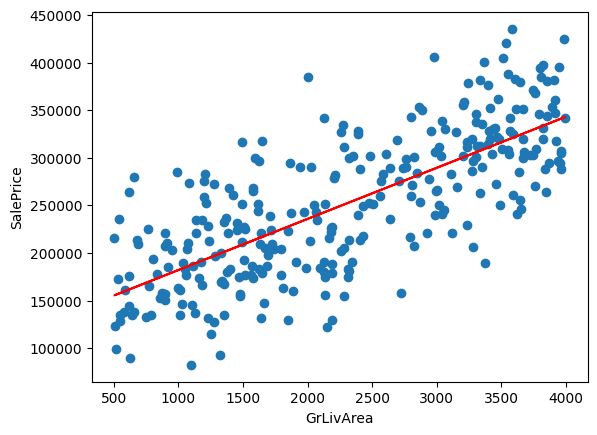

In [ ]:
plt.scatter(x,y)
plt.plot(x,theta0 + theta1*x_norm,color='red')
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

Using sklearn

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,accuracy_score

In [ ]:
X=df.drop(['Id','SalePrice'],axis=1)
y=df['SalePrice']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr_model.predict(X_test)

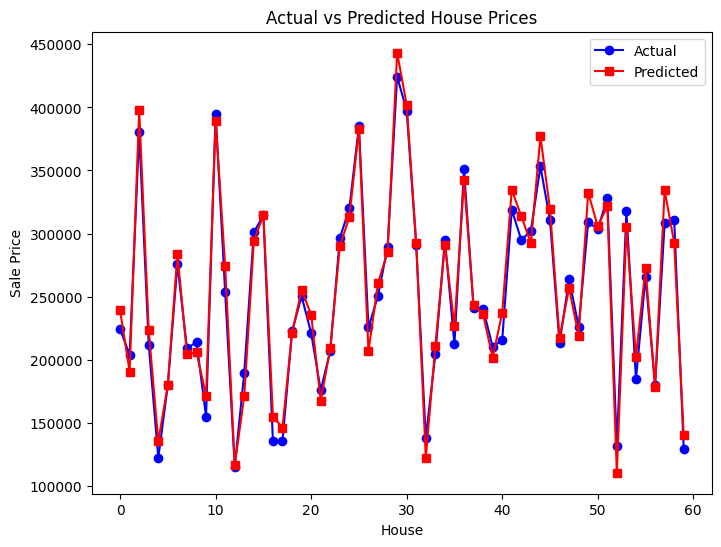

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(y_test.values, color='blue', marker='o', label='Actual')
plt.plot(y_pred_lr, color='red', marker='s', label='Predicted')
# plt.plot(y_pred,color='green',label='ScratchPredicted')
plt.xlabel("House")
plt.ylabel("Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

In [ ]:
R2=r2_score(y_test,y_pred_lr)
MSE=mean_squared_error(y_test,y_pred_lr)
MAE=mean_absolute_error(y_test,y_pred_lr)
RMSE=np.sqrt(MSE)
lrmodel_scores=pd.DataFrame([[R2,MSE,MAE,RMSE]],columns=['R2','MSE','MAE','RMSE'])
print(lrmodel_scores)

         R2           MSE          MAE          RMSE
0  0.972437  1.563865e+08  10431.65598  12505.459265
